Aluna: Nathália Rayanne Lima Araújo

# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

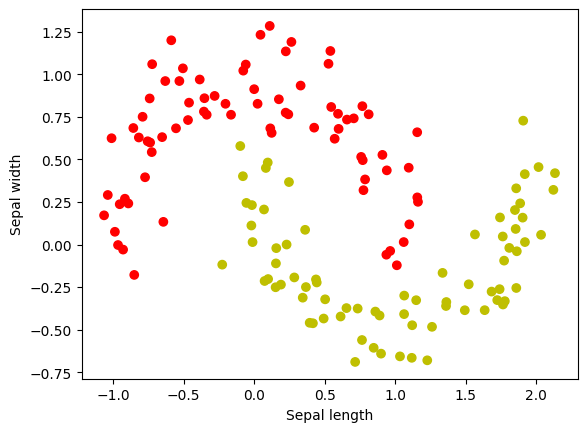

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [5]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [6]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [7]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0024)


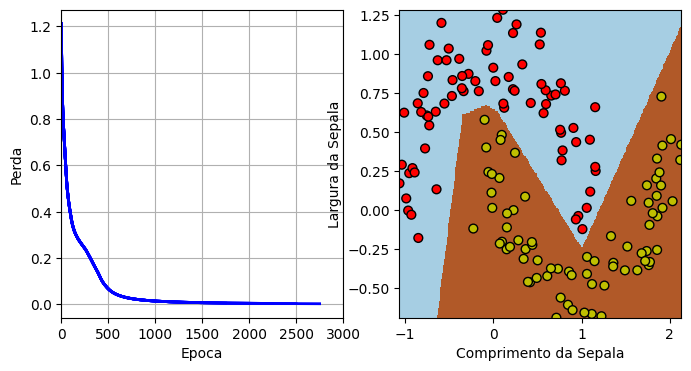

In [8]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [9]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[ 2.5248,  0.1524],
        [-1.5930,  0.5295],
        [-1.7617,  0.2433],
        [ 1.7085,  1.8693],
        [-0.0187, -0.2714]])
dense.0.bias    torch.Size([5])
tensor([-2.4953, -0.2636, -0.3135, -0.5549, -0.1738])
dense.2.weight  torch.Size([5, 5])
tensor([[-0.9679,  0.6815,  1.1942,  1.5657, -0.3967],
        [ 0.9951, -0.1058, -0.8521, -0.6949, -0.4004],
        [ 2.9732, -1.4358, -1.0699, -1.7894,  0.0526],
        [-0.4265, -0.3666,  0.3611, -0.2787, -0.0186],
        [ 1.2259, -0.3309, -0.0260,  0.2414, -0.4050]])
dense.2.bias    torch.Size([5])
tensor([ 0.2650,  0.8087,  2.2275, -0.0229, -0.2738])
dense.4.weight  torch.Size([3, 5])
tensor([[ 1.9129, -0.8563, -2.5390,  0.2268, -0.9749],
        [-1.1797,  1.4185,  3.4945,  0.0277,  0.6869],
        [-0.4379, -0.1552, -1.2540,  0.0807,  0.0440]])
dense.4.bias    torch.Size([3])
tensor([ 2.1521, -0.1520, -1.6491])


### Avaliação do classificador

In [10]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  1.0


### Matriz de confusão

In [11]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,75,0
1,0,75


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

Experimento 1 — Alterar neurônios e camadas

Final loss (Versão A): tensor(0.2771)
Acurácia (Versão A): 0.88


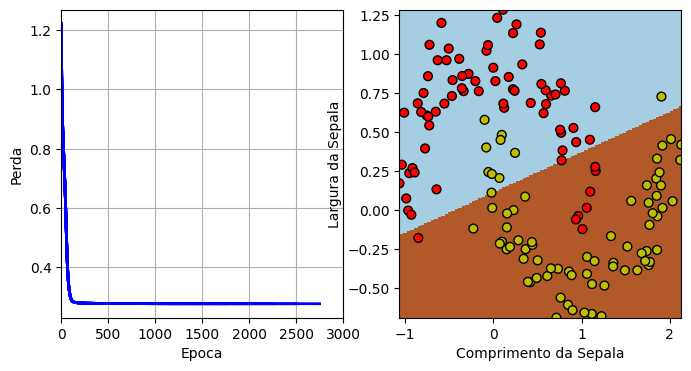

In [16]:
# Versão A: Rede menor (3 neurônios)

class ModeloA(nn.Module):
    def __init__(self):
        super(ModeloA, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 3),
            nn.ReLU(),
            nn.Linear(3, 3),
        )
    def forward(self, x):
        return self.dense(x)

model = ModeloA()
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()
nb_epoch = 3000
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    output = model(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})
print('Final loss (Versão A):', loss.data)
Y_hat = predict(model, X_tensor)
print('Acurácia (Versão A):', (Y_hat == Y).mean())

Final loss (Versão B): tensor(0.0020)
Acurácia (Versão B): 1.0


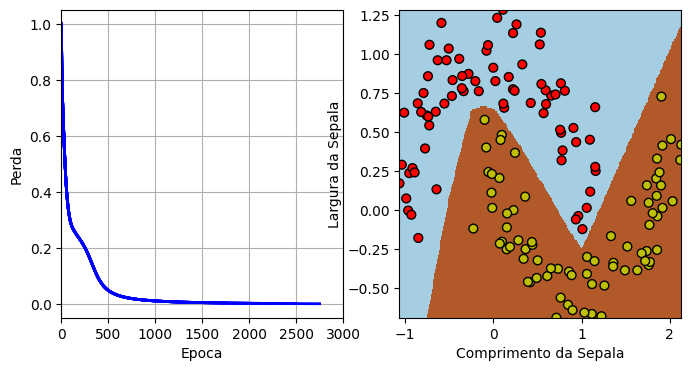

In [17]:
# Versão B: Rede maior (16 neurônios)

class ModeloB(nn.Module):
    def __init__(self):
        super(ModeloB, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
        )
    def forward(self, x):
        return self.dense(x)

model = ModeloB()
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()
nb_epoch = 3000
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    output = model(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})
print('Final loss (Versão B):', loss.data)
Y_hat = predict(model, X_tensor)
print('Acurácia (Versão B):', (Y_hat == Y).mean())

Final loss (Versão C): tensor(0.0002)
Acurácia (Versão C): 1.0


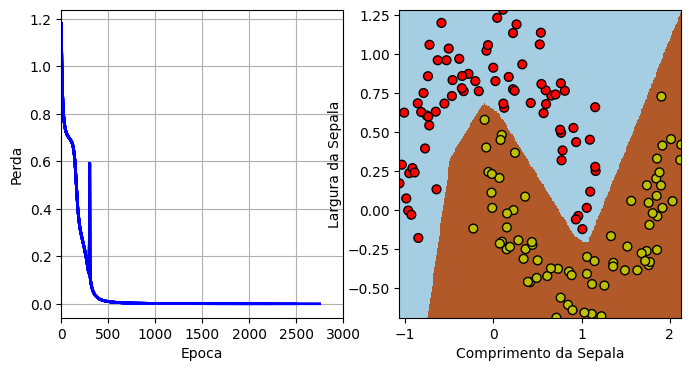

In [18]:
# Versão C: Mais camadas (4 camadas escondidas)

class ModeloC(nn.Module):
    def __init__(self):
        super(ModeloC, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 3),
        )
    def forward(self, x):
        return self.dense(x)

model = ModeloC()
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()
nb_epoch = 3000
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    output = model(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})
print('Final loss (Versão C):', loss.data)
Y_hat = predict(model, X_tensor)
print('Acurácia (Versão C):', (Y_hat == Y).mean())

Experimento 2 — Trocar ReLU por Sigmoid

Final loss (Sigmoid): tensor(0.2851)
Acurácia (Sigmoid): 0.88


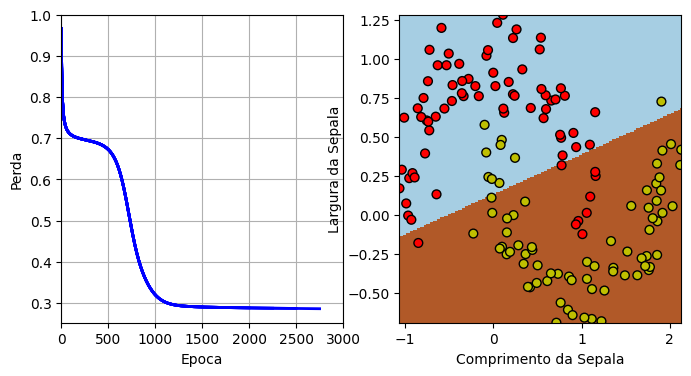

In [19]:
class ModeloSigmoid(nn.Module):
    def __init__(self):
        super(ModeloSigmoid, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Sigmoid(),
            nn.Linear(5, 5),
            nn.Sigmoid(),
            nn.Linear(5, 3),
        )
    def forward(self, x):
        return self.dense(x)

model = ModeloSigmoid()
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()
nb_epoch = 3000
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    output = model(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})
print('Final loss (Sigmoid):', loss.data)
Y_hat = predict(model, X_tensor)
print('Acurácia (Sigmoid):', (Y_hat == Y).mean())

Experimento 3 — Sem ativação não linear

In [ ]:
class ModeloSemAtivacao(nn.Module):
    def __init__(self):
        super(ModeloSemAtivacao, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Linear(5, 5),
            nn.Linear(5, 3),
        )
    def forward(self, x):
        return self.dense(x)

model = ModeloSemAtivacao()
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()
nb_epoch = 3000
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    output = model(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})
print('Final loss (Sem ativação):', loss.data)
Y_hat = predict(model, X_tensor)
print('Acurácia (Sem ativação):', (Y_hat == Y).mean())

## Principais aprendizados

Os experimentos realizados mostraram como a arquitetura de uma rede neural influencia diretamente seu desempenho. O aumento do número de neurônios amplia a capacidade do modelo de aprender padrões mais complexos, porém, em conjuntos de dados pequenos, como o Iris, o excesso de neurônios pode causar *overfitting*, fazendo com que a rede memorize os dados em vez de generalizar corretamente.

Também foi possível compreender que o uso de múltiplas camadas permite um aprendizado hierárquico, no qual cada camada aprende representações mais elaboradas dos dados.
Outro aprendizado importante foi a diferença entre as funções de ativação. A função ReLU apresentou melhor desempenho nas camadas escondidas por convergir mais rapidamente e evitar o problema de vanishing gradient. Já a função Sigmoid é mais adequada para saídas de classificação binária.

Além disso, a não linearidade é essencial para o poder das redes neurais. Sem funções de ativação não lineares, mesmo redes com várias camadas se comportam matematicamente como uma simples regressão linear, limitando significativamente sua capacidade de aprendizado.